Loaded PV_01cm_ramp.csv: 151 samples
Loaded PV_05cm_ramp.csv: 145 samples
Loaded PV_10cm_ramp.csv: 129 samples
Loaded PV_15cm_ramp.csv: 96 samples
Loaded PV_20cm_ramp.csv: 77 samples


,test,samples,max_voltage_V,current_at_max_voltage_mA,max_current_mA,voltage_at_max_current_V,max_power_mW,voltage_at_max_power_V,current_at_max_power_mA
0,01 cm,151,4.591,-0.075,112.075,0.275,396.875,3.985,99.675
1,05 cm,145,4.501,-0.100,111.800,0.280,360.625,4.037,89.250
2,10 cm,129,4.280,-0.075,98.975,0.239,305.625,3.835,79.750
3,15 cm,96,4.202,-0.075,69.925,0.172,214.375,3.584,59.725
4,20 cm,77,4.140,-0.100,55.825,1.024,166.875,3.715,44.875


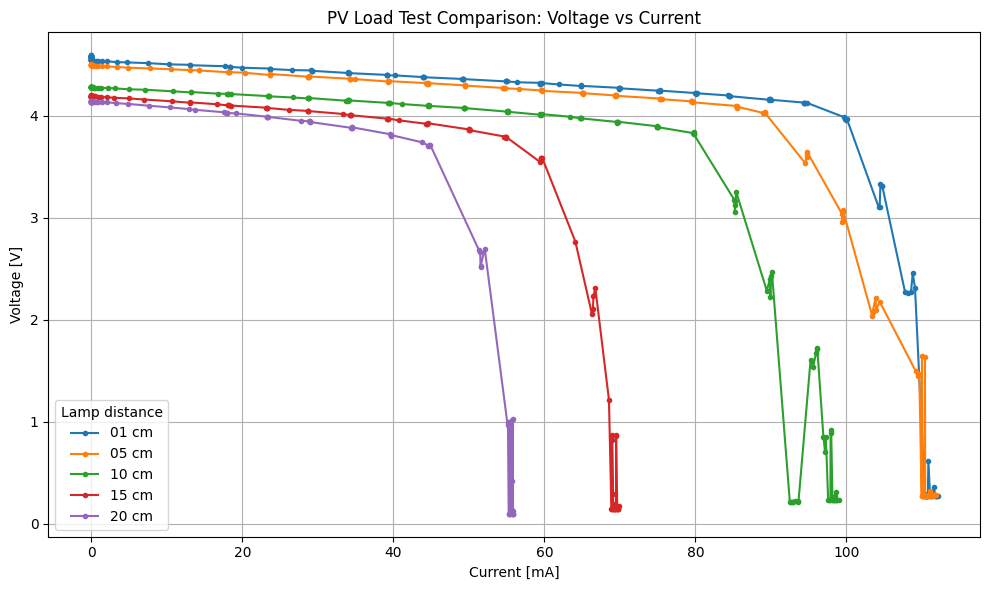

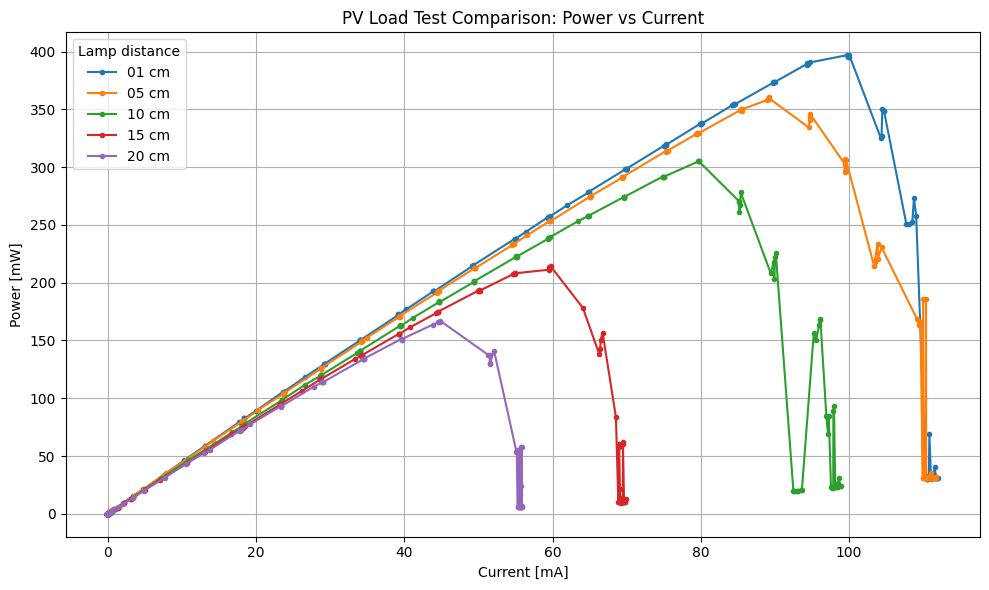

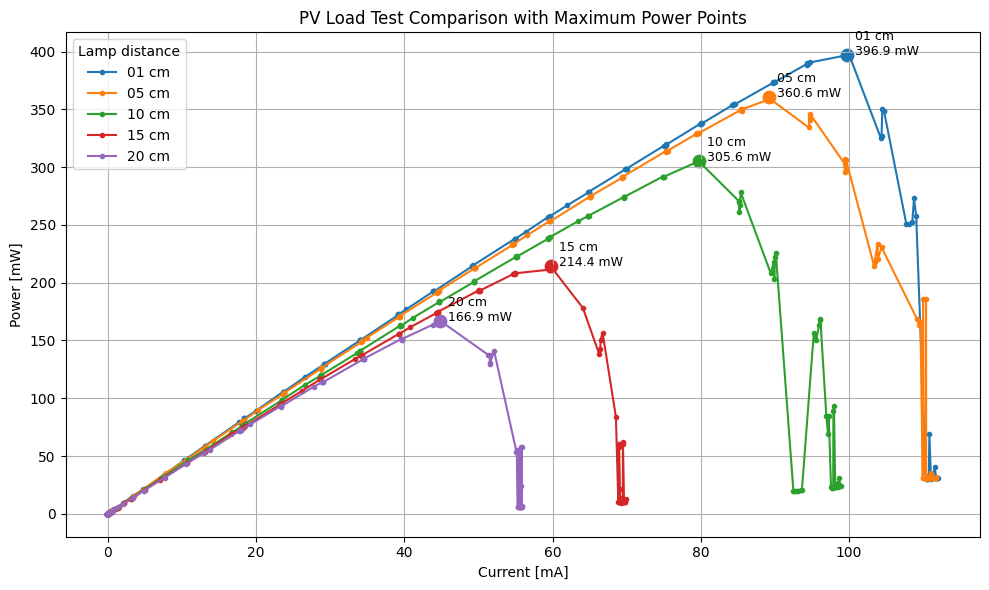

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# Settings

files = [
    "PV_01cm_ramp.csv",
    "PV_05cm_ramp.csv",
    "PV_10cm_ramp.csv",
    "PV_15cm_ramp.csv",
    "PV_20cm_ramp.csv",
]

data_folder = Path(".")   # Folder containing CSV files

V_COL = "ina3_bus_V"
I_COL = "ina3_current_mA"
P_COL = "ina3_power_mW"



# Helper functions
def label_from_filename(filename):
    """
    Converts PV_01cm_ramp.csv to 01 cm.
    """
    name = Path(filename).stem
    distance = name.split("_")[1]
    return distance.replace("cm", " cm")


def load_pv_file(filepath):
    """
    Loads and cleans one PV ramp CSV file.
    """
    df = pd.read_csv(filepath)

    df = df[[V_COL, I_COL, P_COL]].copy()

    df[V_COL] = pd.to_numeric(df[V_COL], errors="coerce")
    df[I_COL] = pd.to_numeric(df[I_COL], errors="coerce")
    df[P_COL] = pd.to_numeric(df[P_COL], errors="coerce")

    df = df.dropna()

    # Sort by current for smoother comparison plots
    df = df.sort_values(I_COL)

    return df


def calculate_summary(df, label):
    """
    Calculates max voltage, current, power, and MPP values.
    """

    idx_pmax = df[P_COL].idxmax()
    idx_vmax = df[V_COL].idxmax()
    idx_imax = df[I_COL].idxmax()

    return {
        "test": label,
        "samples": len(df),

        "max_voltage_V": df.loc[idx_vmax, V_COL],
        "current_at_max_voltage_mA": df.loc[idx_vmax, I_COL],

        "max_current_mA": df.loc[idx_imax, I_COL],
        "voltage_at_max_current_V": df.loc[idx_imax, V_COL],

        "max_power_mW": df.loc[idx_pmax, P_COL],
        "voltage_at_max_power_V": df.loc[idx_pmax, V_COL],
        "current_at_max_power_mA": df.loc[idx_pmax, I_COL],
    }



# Load all files


pv_data = {}
summary_rows = []

for file in files:
    filepath = data_folder / file
    label = label_from_filename(file)

    df = load_pv_file(filepath)

    pv_data[label] = df
    summary_rows.append(calculate_summary(df, label))

    print(f"Loaded {file}: {len(df)} samples")


summary_df = pd.DataFrame(summary_rows)

# Round for readability
summary_df = summary_df.round({
    "max_voltage_V": 3,
    "current_at_max_voltage_mA": 3,
    "max_current_mA": 3,
    "voltage_at_max_current_V": 3,
    "max_power_mW": 3,
    "voltage_at_max_power_V": 3,
    "current_at_max_power_mA": 3,
})

display(summary_df)


# Combined comparison plot: Voltage vs Current


plt.figure(figsize=(10, 6))

for label, df in pv_data.items():
    plt.plot(
        df[I_COL],
        df[V_COL],
        marker=".",
        linewidth=1.5,
        label=label
    )

plt.xlabel("Current [mA]")
plt.ylabel("Voltage [V]")
plt.title("PV Load Test Comparison: Voltage vs Current")
plt.grid(True)
plt.legend(title="Lamp distance")
plt.tight_layout()
plt.show()



# Combined comparison plot: Power vs Current
plt.figure(figsize=(10, 6))

for label, df in pv_data.items():
    plt.plot(
        df[I_COL],
        df[P_COL],
        marker=".",
        linewidth=1.5,
        label=label
    )

plt.xlabel("Current [mA]")
plt.ylabel("Power [mW]")
plt.title("PV Load Test Comparison: Power vs Current")
plt.grid(True)
plt.legend(title="Lamp distance")
plt.tight_layout()
plt.show()


# maximum power points on Power vs Current plot


plt.figure(figsize=(10, 6))

for label, df in pv_data.items():
    plt.plot(
        df[I_COL],
        df[P_COL],
        marker=".",
        linewidth=1.5,
        label=label
    )

    idx_pmax = df[P_COL].idxmax()
    i_mpp = df.loc[idx_pmax, I_COL]
    p_mpp = df.loc[idx_pmax, P_COL]

    plt.scatter(i_mpp, p_mpp, s=80)
    plt.text(
        i_mpp,
        p_mpp,
        f"  {label}\n  {p_mpp:.1f} mW",
        fontsize=9
    )

plt.xlabel("Current [mA]")
plt.ylabel("Power [mW]")
plt.title("PV Load Test Comparison with Maximum Power Points")
plt.grid(True)
plt.legend(title="Lamp distance")
plt.tight_layout()
plt.show()

Loaded PV_01cm_ramp.csv: 151 samples
Loaded PV_05cm_ramp.csv: 145 samples
Loaded PV_10cm_ramp.csv: 129 samples
Loaded PV_15cm_ramp.csv: 96 samples
Loaded PV_20cm_ramp.csv: 77 samples


,test,samples,max_voltage_V,current_at_max_voltage_mA,max_current_mA,voltage_at_max_current_V,max_power_mW,voltage_at_max_power_V,current_at_max_power_mA
0,01 cm,151,4.591,-0.075,112.075,0.275,396.875,3.985,99.675
1,05 cm,145,4.501,-0.100,111.800,0.280,360.625,4.037,89.250
2,10 cm,129,4.280,-0.075,98.975,0.239,305.625,3.835,79.750
3,15 cm,96,4.202,-0.075,69.925,0.172,214.375,3.584,59.725
4,20 cm,77,4.140,-0.100,55.825,1.024,166.875,3.715,44.875


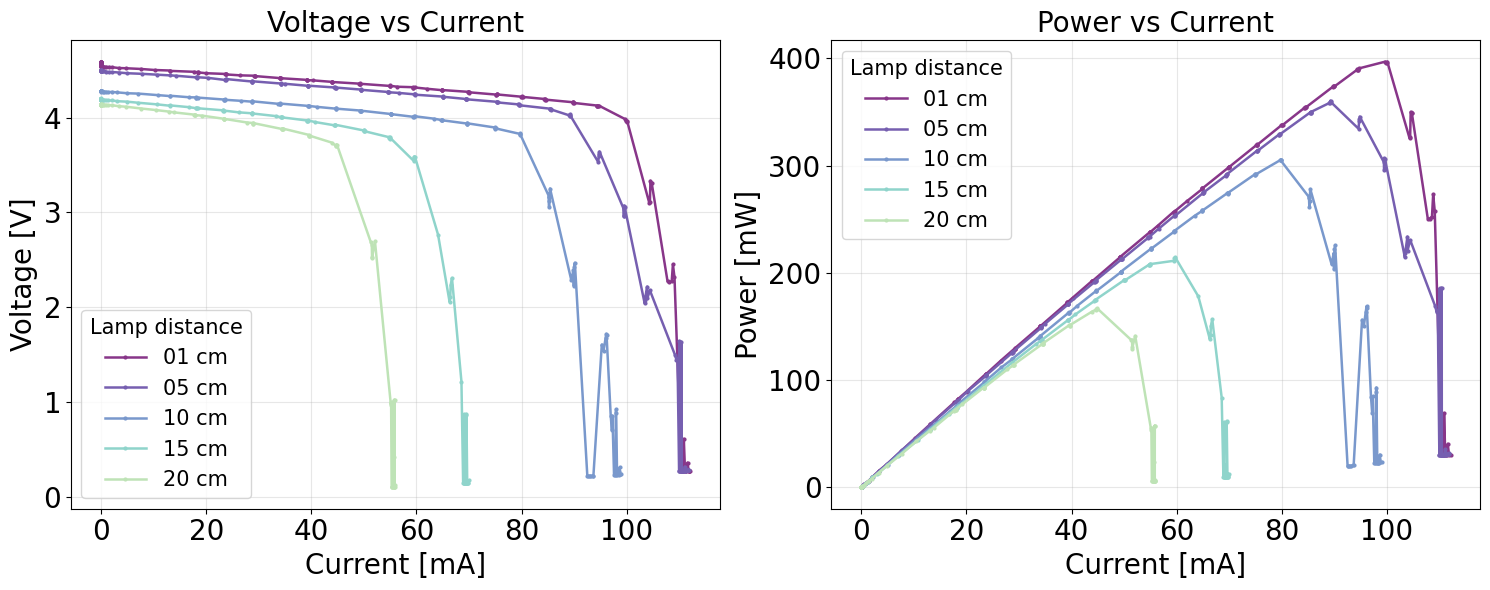

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# settings

# Font sizes
TITLE_SIZE = 18
SUBTITLE_SIZE = 20
LABEL_SIZE = 20
TICK_SIZE = 20
LEGEND_SIZE = 15
LEGEND_TITLE_SIZE = 15

files = [
    "PV_01cm_ramp.csv",
    "PV_05cm_ramp.csv",
    "PV_10cm_ramp.csv",
    "PV_15cm_ramp.csv",
    "PV_20cm_ramp.csv",
]

data_folder = Path(".")   # Folder containing CSV files

V_COL = "ina3_bus_V"
I_COL = "ina3_current_mA"
P_COL = "ina3_power_mW"

# Professional blue palette
BLUE_PALETTE = [
    "#883689",
    "#765fb0",
    "#7998cc",
    "#8fd4cb",
    "#bee3b6",
]



# Functions


def label_from_filename(filename):
    """
    Converts PV_01cm_ramp.csv to 01 cm.
    """
    name = Path(filename).stem
    distance = name.split("_")[1]
    return distance.replace("cm", " cm")


def load_pv_file(filepath):
    """
    Loads and cleans one PV ramp CSV file.
    """
    df = pd.read_csv(filepath)

    df = df[[V_COL, I_COL, P_COL]].copy()

    df[V_COL] = pd.to_numeric(df[V_COL], errors="coerce")
    df[I_COL] = pd.to_numeric(df[I_COL], errors="coerce")
    df[P_COL] = pd.to_numeric(df[P_COL], errors="coerce")

    df = df.dropna()

    # Sort by current for smoother comparison plots
    df = df.sort_values(I_COL)

    return df


def calculate_summary(df, label):
    """
    Calculates max voltage, current, power, and MPP values.
    """
    idx_pmax = df[P_COL].idxmax()
    idx_vmax = df[V_COL].idxmax()
    idx_imax = df[I_COL].idxmax()

    return {
        "test": label,
        "samples": len(df),

        "max_voltage_V": df.loc[idx_vmax, V_COL],
        "current_at_max_voltage_mA": df.loc[idx_vmax, I_COL],

        "max_current_mA": df.loc[idx_imax, I_COL],
        "voltage_at_max_current_V": df.loc[idx_imax, V_COL],

        "max_power_mW": df.loc[idx_pmax, P_COL],
        "voltage_at_max_power_V": df.loc[idx_pmax, V_COL],
        "current_at_max_power_mA": df.loc[idx_pmax, I_COL],
    }


def plot_pv_comparison(pv_data):
    """
    Creates side-by-side comparison plots:
    1. Voltage vs Current
    2. Power vs Current
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    ax_voltage = axes[0]
    ax_power = axes[1]

    for color, (label, df) in zip(BLUE_PALETTE, pv_data.items()):
        # Voltage vs Current
        ax_voltage.plot(
            df[I_COL],
            df[V_COL],
            marker=".",
            linewidth=1.8,
            markersize=4,
            color=color,
            label=label
        )

        # Power vs Current
        ax_power.plot(
            df[I_COL],
            df[P_COL],
            marker=".",
            linewidth=1.8,
            markersize=4,
            color=color,
            label=label
        )


    # Formatting: Voltage plot

    ax_voltage.set_xlabel("Current [mA]", fontsize=LABEL_SIZE)
    ax_voltage.set_ylabel("Voltage [V]", fontsize=LABEL_SIZE)
    ax_voltage.set_title("Voltage vs Current", fontsize=SUBTITLE_SIZE)
    ax_voltage.tick_params(axis="both", labelsize=TICK_SIZE)
    ax_voltage.grid(True, alpha=0.3)

    legend_voltage = ax_voltage.legend(
        title="Lamp distance",
        fontsize=LEGEND_SIZE,
        title_fontsize=LEGEND_TITLE_SIZE
    )


    # Formatting: Power plot

    ax_power.set_xlabel("Current [mA]", fontsize=LABEL_SIZE)
    ax_power.set_ylabel("Power [mW]", fontsize=LABEL_SIZE)
    ax_power.set_title("Power vs Current", fontsize=SUBTITLE_SIZE)
    ax_power.tick_params(axis="both", labelsize=TICK_SIZE)
    ax_power.grid(True, alpha=0.3)

    legend_power = ax_power.legend(
        title="Lamp distance",
        fontsize=LEGEND_SIZE,
        title_fontsize=LEGEND_TITLE_SIZE
    )


    # Overall formatting

    # fig.suptitle(
    #     "PV Load Test Comparison",
    #     fontsize=TITLE_SIZE,
    #     fontweight="bold"
    # )

    plt.tight_layout()
    plt.show()


# Load all files

pv_data = {}
summary_rows = []

for file in files:
    filepath = data_folder / file
    label = label_from_filename(file)

    df = load_pv_file(filepath)

    pv_data[label] = df
    summary_rows.append(calculate_summary(df, label))

    print(f"Loaded {file}: {len(df)} samples")



# Summary table

summary_df = pd.DataFrame(summary_rows)

summary_df = summary_df.round({
    "max_voltage_V": 3,
    "current_at_max_voltage_mA": 3,
    "max_current_mA": 3,
    "voltage_at_max_current_V": 3,
    "max_power_mW": 3,
    "voltage_at_max_power_V": 3,
    "current_at_max_power_mA": 3,
})

display(summary_df)



# Side-by-side comparison plots

plot_pv_comparison(pv_data)